## Experiment 3: Email Spam or Ham Classification using Naive Bayes, KNN, and SVM

`` NAME : Harishkanna R ``\
`` REG : 3122235001302``\
`` SEC : CSE-A``

## 1. Aim and Objectives

### Aim

The aim of this experiment is to design and implement machine learning models for classifying emails as **spam** or **ham**. This experiment focuses on applying **Naïve Bayes**, **K-Nearest Neighbors (KNN)**, and **Support Vector Machine (SVM)** algorithms to understand how different classifiers and their variants perform on real-world email data. The experiment also aims to analyze model effectiveness using standard evaluation metrics and validation techniques.


### Objectives

- To preprocess and analyze the email dataset using exploratory data analysis (EDA) techniques.  
- To build and train Naïve Bayes, KNN, and SVM classifiers with different variants and parameter settings.  
- To evaluate and compare model performance using accuracy, precision, recall, F1-score, ROC curve, and confusion matrix.  
- To perform K-Fold cross-validation and identify the most effective classifier for email spam detection.


## 2 Libraries Used

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import StandardScaler

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report


## 3 Code for All Variants and Models
### 3.1 1: Load and preprocess the dataset (missing values, normalization)

In [120]:
import pandas as pd

# Load dataset
df = pd.read_csv("spambase_csv.csv")

# Show first 5 rows
df.head()


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [121]:
print("Shape:", df.shape)
df.info()


Shape: (4601, 58)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_repor

In [122]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_tel

In [123]:
X = df.drop('class', axis=1)
y = df['class']


In [124]:
df.shape

(4601, 58)

In [125]:
df.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


## 3.2 Exploratory Data Analysis (EDA)

In [142]:
print("\nClass Distribution:")
print(df.iloc[:, -1].value_counts())


Class Distribution:
class
0    2788
1    1813
Name: count, dtype: int64


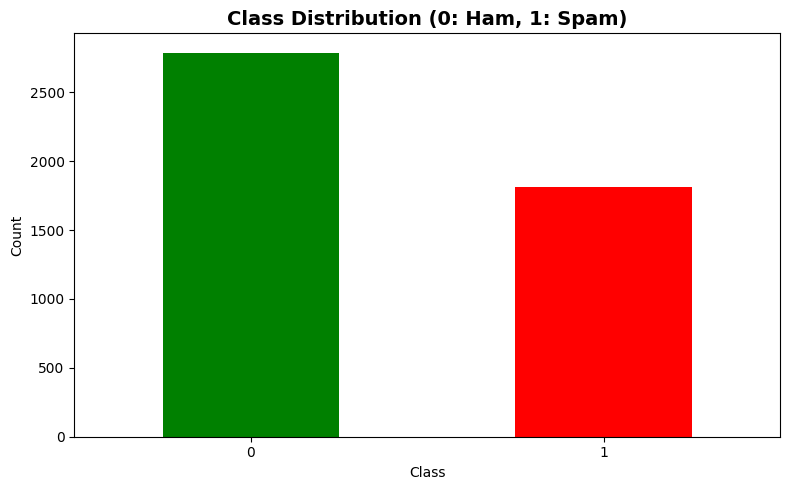

In [143]:
plt.figure(figsize=(8, 5))
df.iloc[:, -1].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution (0: Ham, 1: Spam)', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [144]:
class_counts = df.iloc[:, -1].value_counts()
print(f"\nClass Balance:")
print(f"Ham (0): {class_counts[0]/len(df)*100:.2f}%")
print(f"Spam (1): {class_counts[1]/len(df)*100:.2f}%")


Class Balance:
Ham (0): 60.60%
Spam (1): 39.40%


In [145]:
features=df.columns[:-1]
len(features)

57

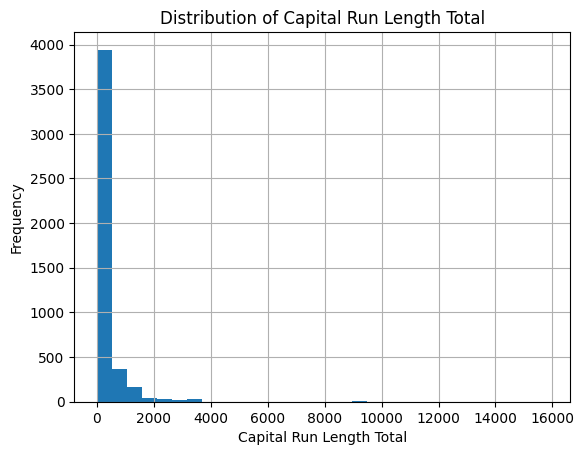

In [128]:
plt.figure()
df['capital_run_length_total'].hist(bins=30)
plt.xlabel("Capital Run Length Total")
plt.ylabel("Frequency")
plt.title("Distribution of Capital Run Length Total")
plt.show()


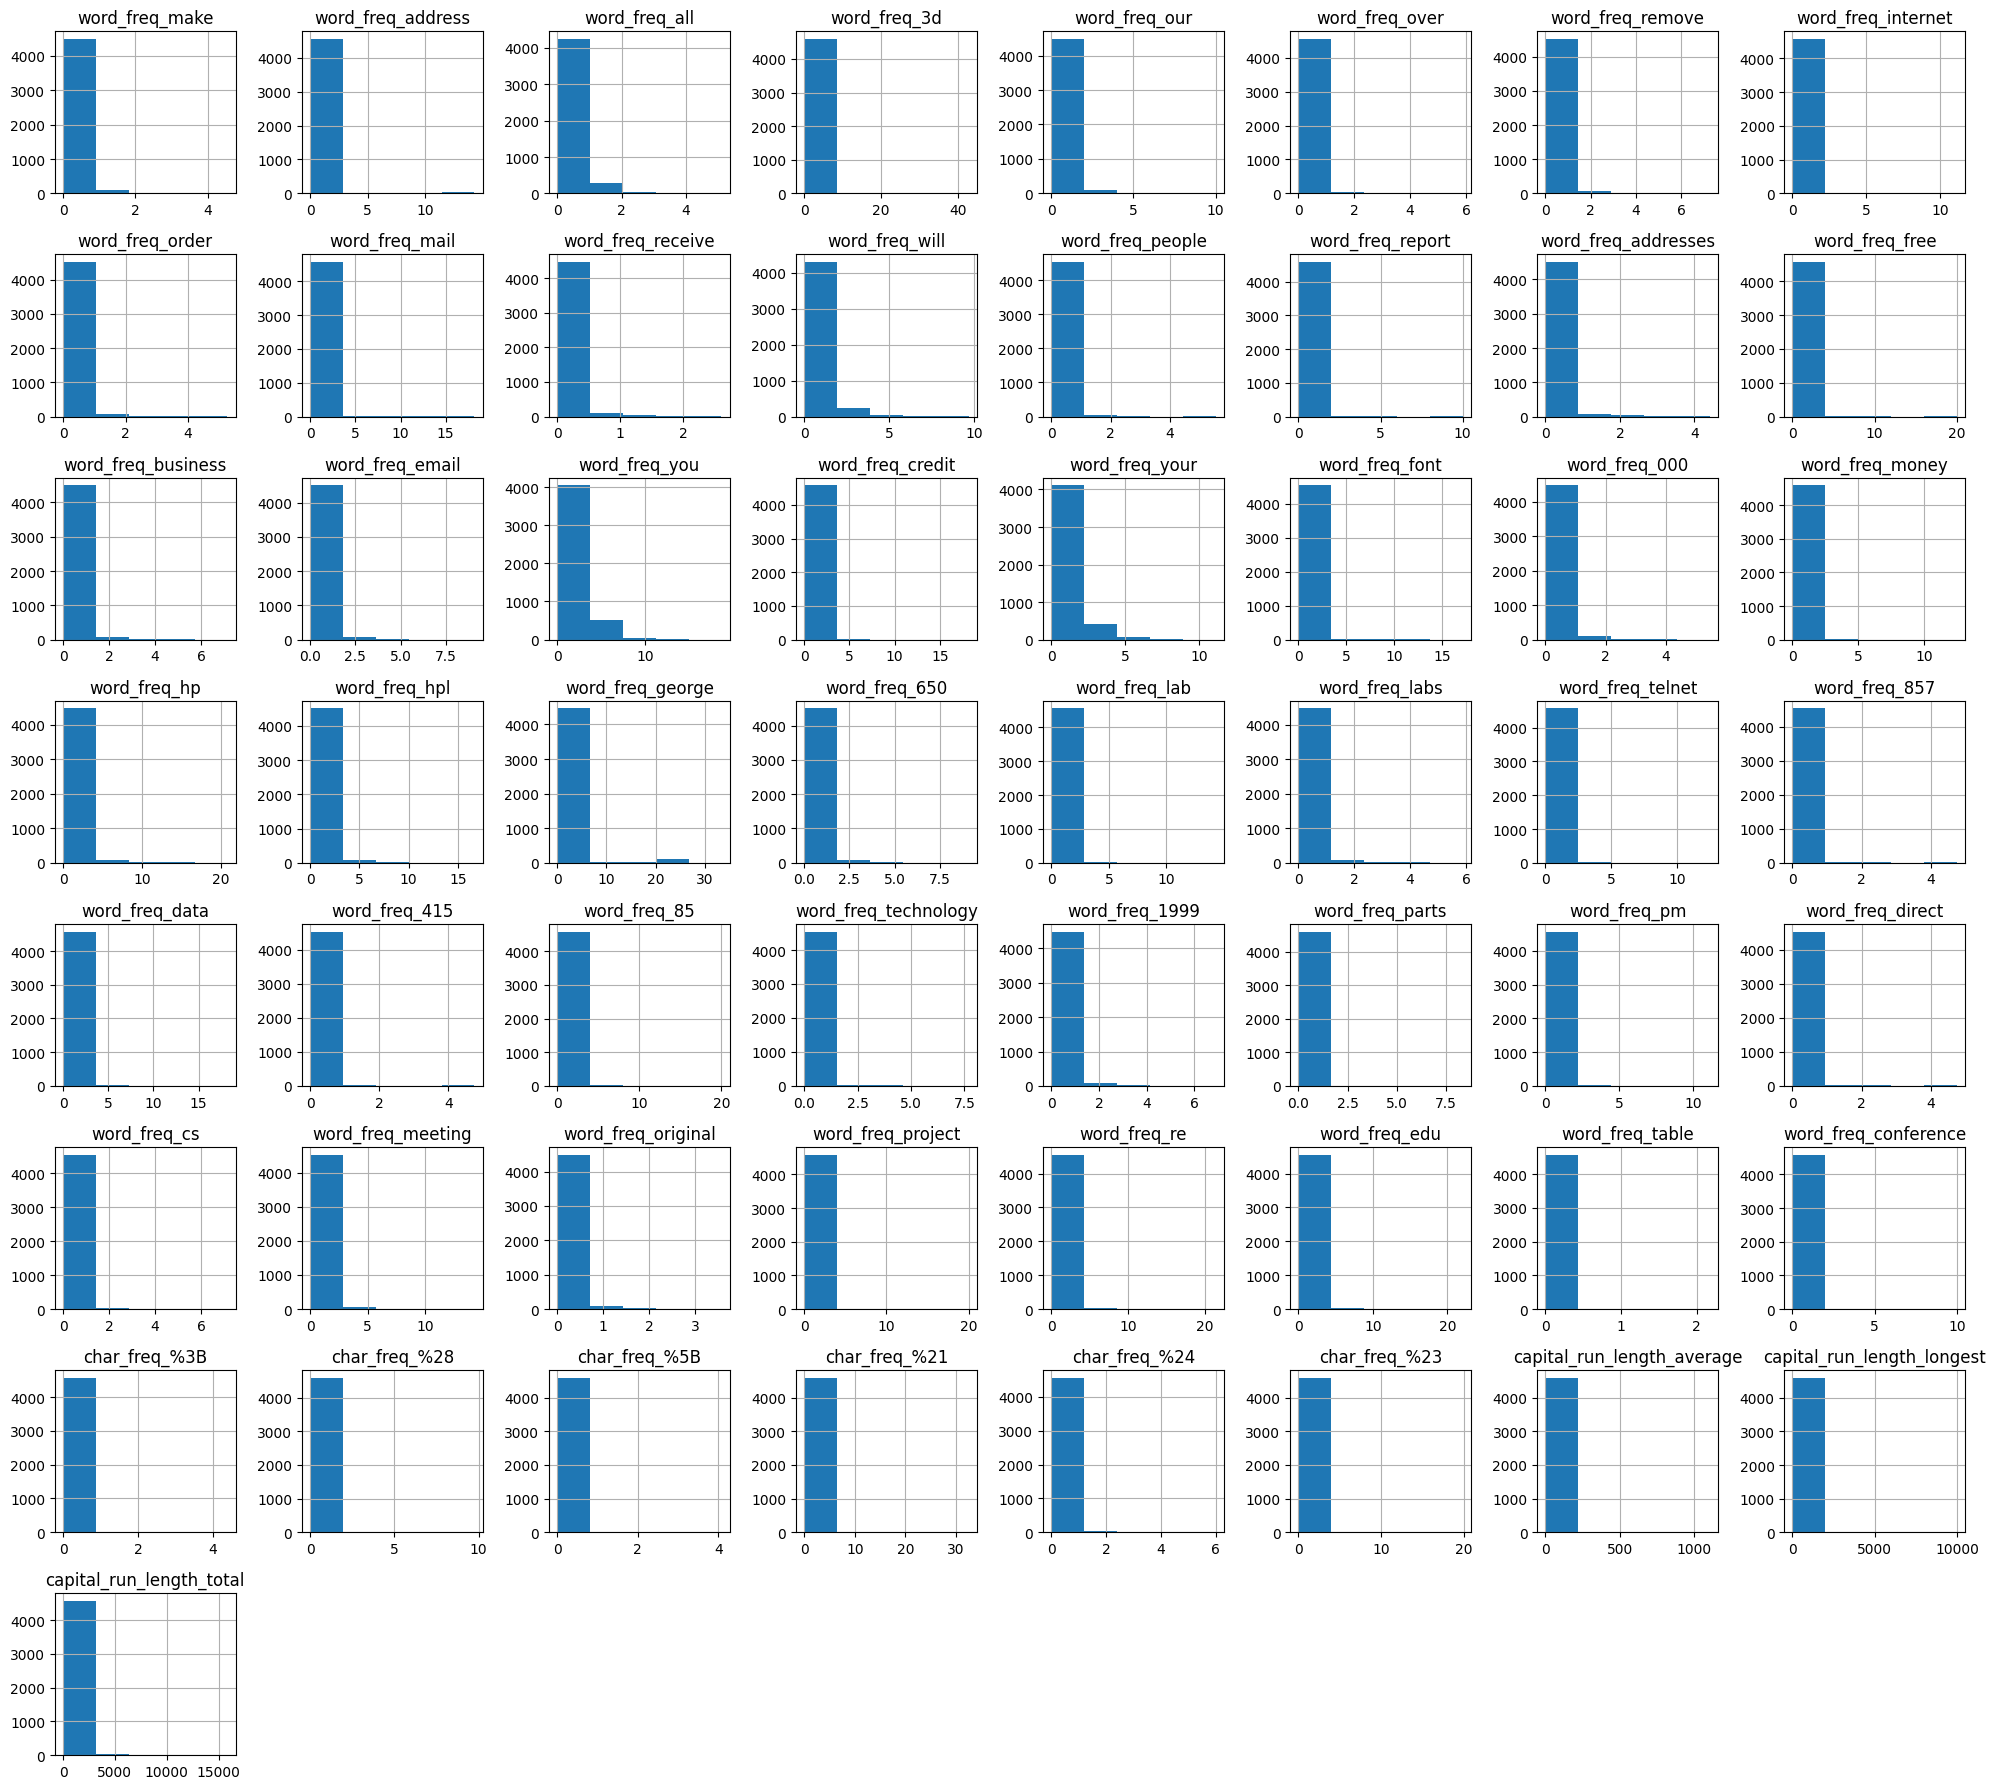

In [147]:
df[features].hist(bins=5,figsize=(20,18))
plt.tight_layout()
plt.show()

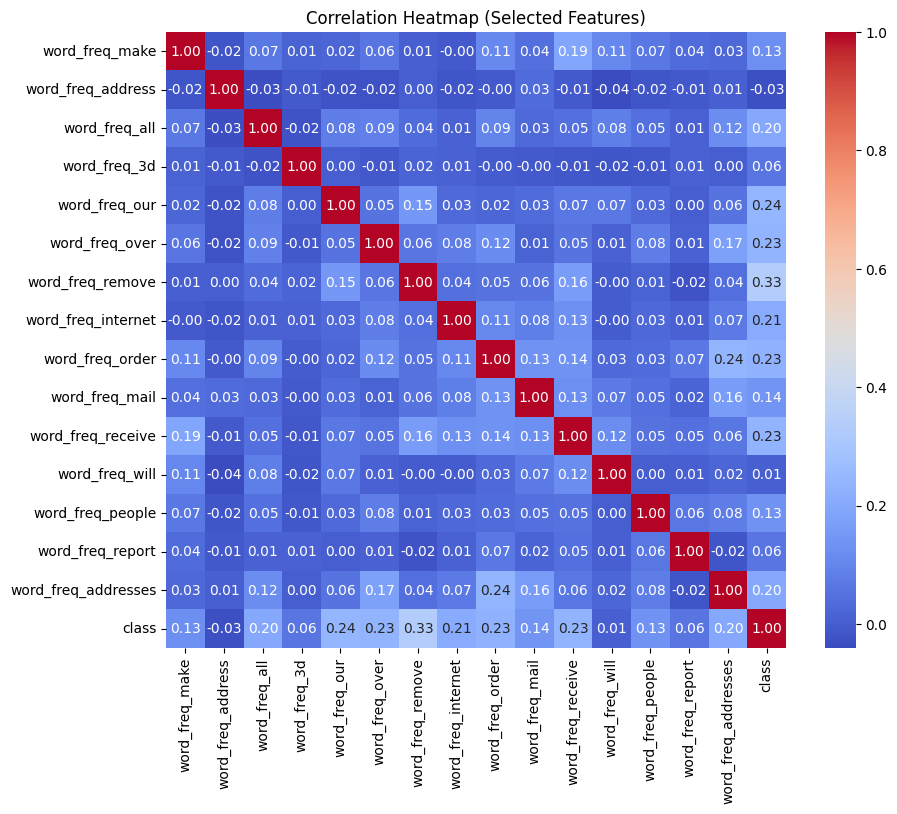

In [129]:
# Select a subset of features for clarity
selected_features = list(X.columns[:15]) + ['class']

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap (Selected Features)")
plt.show()


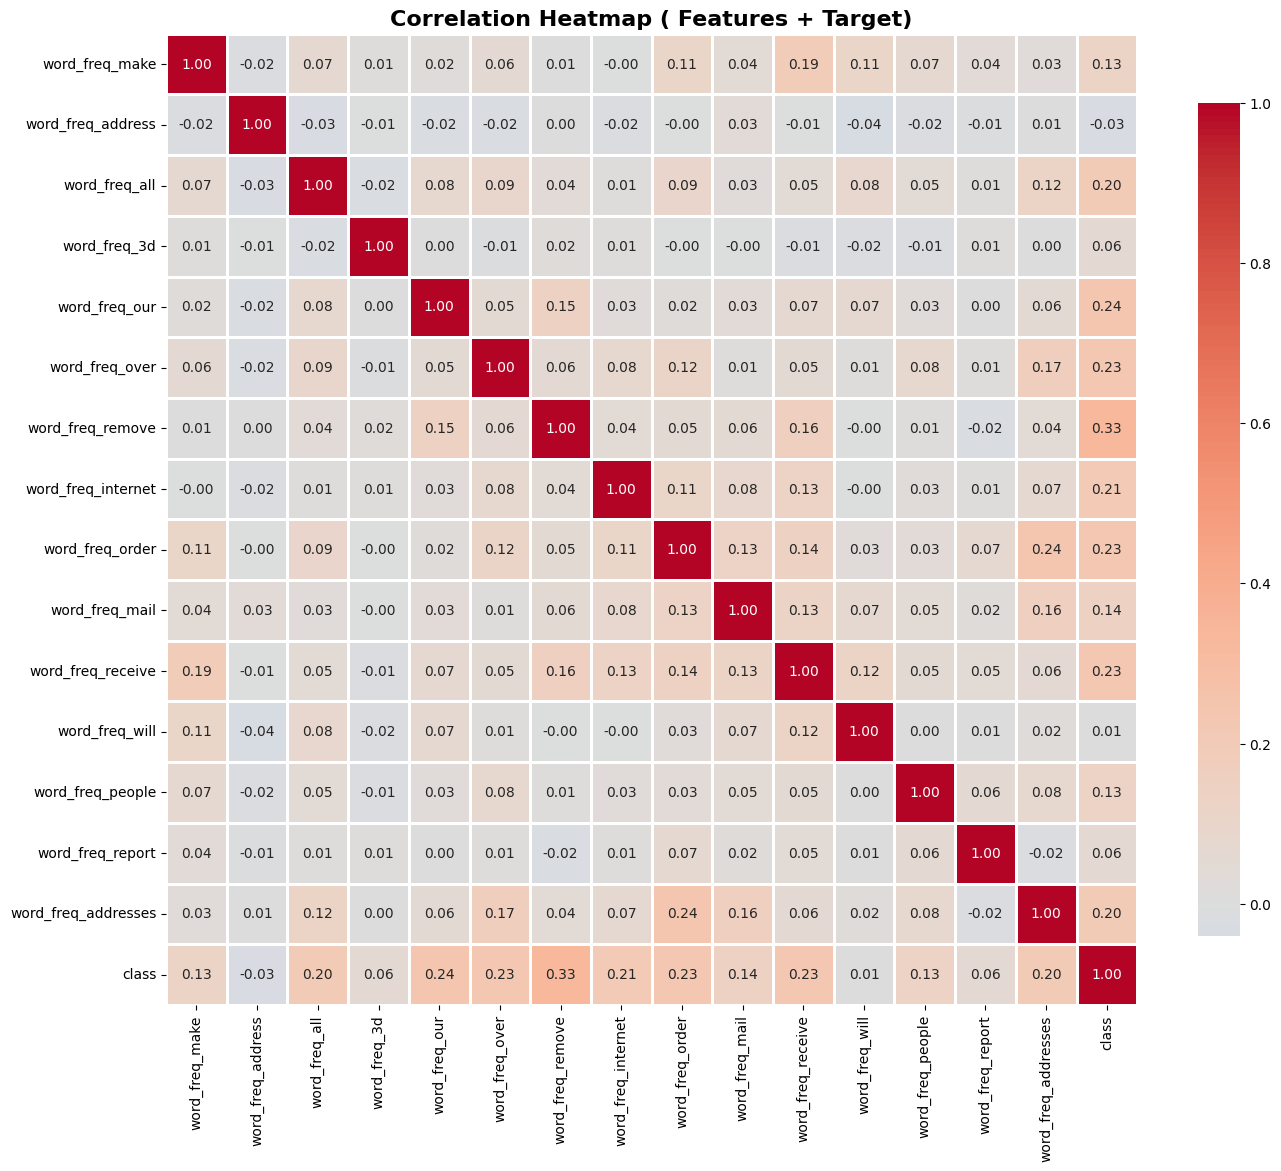

In [130]:

correlation_matrix = df[selected_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap ( Features + Target)', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

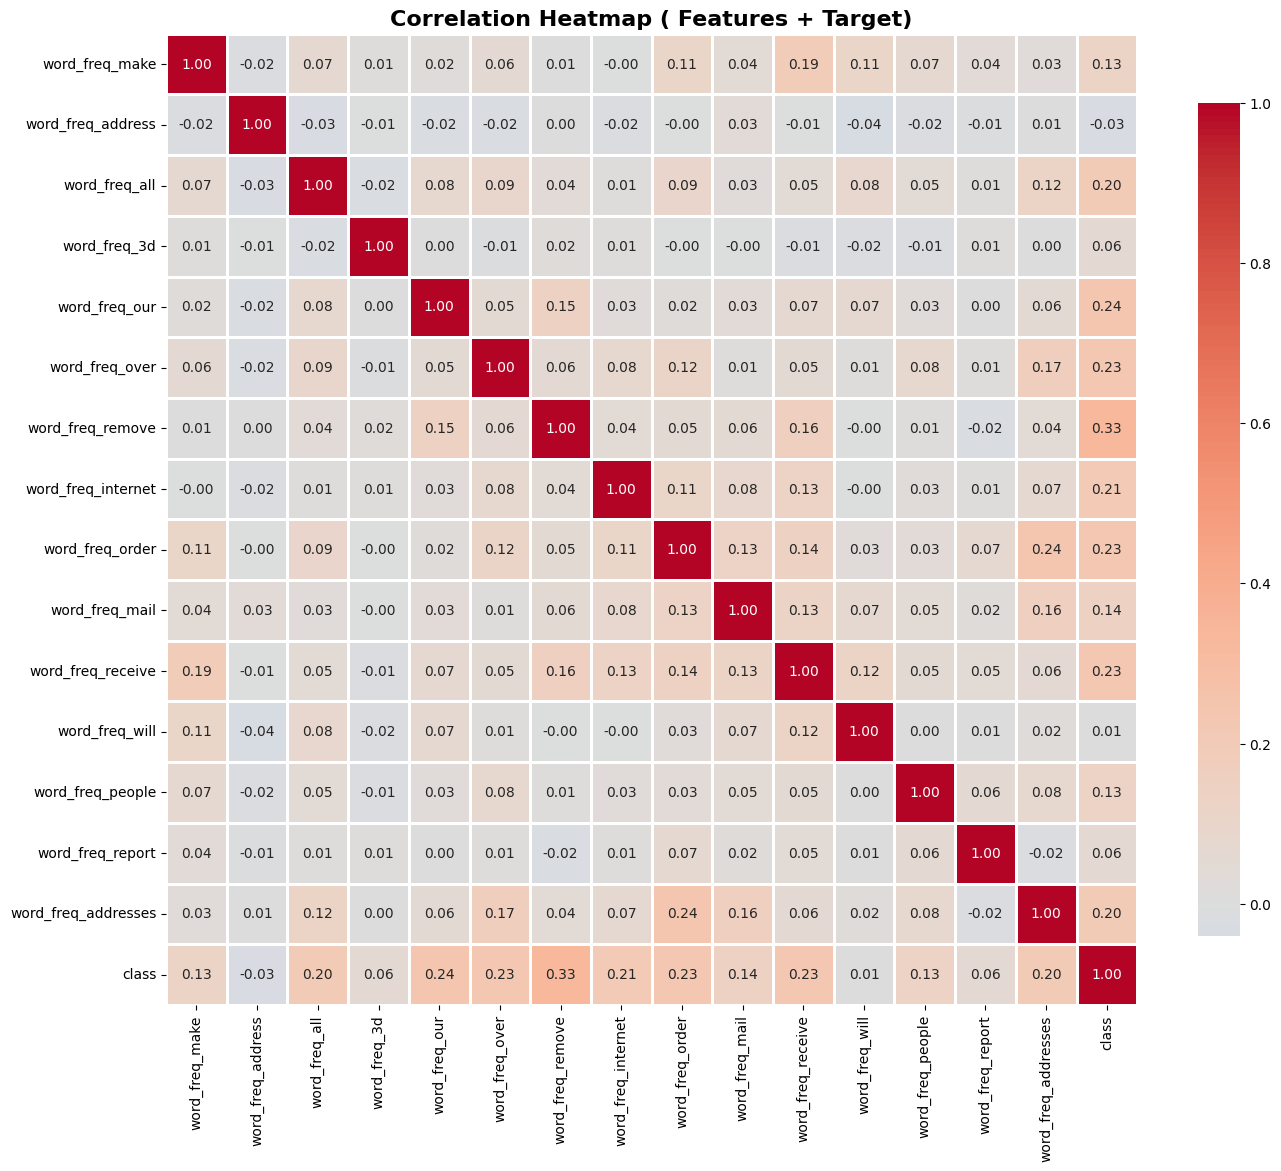

In [131]:


import seaborn as sns
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap ( Features + Target)', 
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [148]:
corr_label=df.corr()["class"].sort_values(ascending=False)
corr_label

class                         1.000000
word_freq_your                0.383234
word_freq_000                 0.334787
word_freq_remove              0.332117
char_freq_%24                 0.323629
word_freq_you                 0.273651
word_freq_free                0.263215
word_freq_business            0.263204
capital_run_length_total      0.249164
word_freq_our                 0.241920
char_freq_%21                 0.241888
word_freq_receive             0.234529
word_freq_over                0.232604
word_freq_order               0.231551
word_freq_money               0.216111
capital_run_length_longest    0.216097
word_freq_internet            0.206808
word_freq_email               0.204208
word_freq_all                 0.196988
word_freq_addresses           0.195902
word_freq_credit              0.189761
word_freq_mail                0.138962
word_freq_people              0.132927
word_freq_make                0.126208
capital_run_length_average    0.109999
word_freq_font           

### 3.3 3:Split into train and test sets.

In [150]:
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [151]:
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Features shape: (4601, 57)
Target shape: (4601,)

Training set size: 3220
Test set size: 1381


In [152]:
from sklearn.preprocessing import MinMaxScaler
scaler =MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [154]:
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"\n{'='*60}")
    print(f"{model_name} - Performance Metrics")
    print(f"{'='*60}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    return {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1
    }


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam'])
    plt.title(f'Confusion Matrix - {title}', fontsize=14, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    return cm
def plot_roc_curve(y_true, y_pred_proba, title):
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
        label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {title}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return roc_auc


### 3.4 4: Training the Models

### 3.4.1Naive Bayes Variant
### 1.GaussianNB

In [155]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred_gnb = gnb.predict(X_test_scaled)
y_pred_proba_gnb = gnb.predict_proba(X_test_scaled)[:, 1]
nb_results={}
nb_results['Gaussian NB'] = evaluate_model(y_test, y_pred_gnb, "Gaussian Naive Bayes")


Gaussian Naive Bayes - Performance Metrics
Accuracy: 0.8197
Precision: 0.7001
Recall: 0.9485
F1-Score: 0.8056


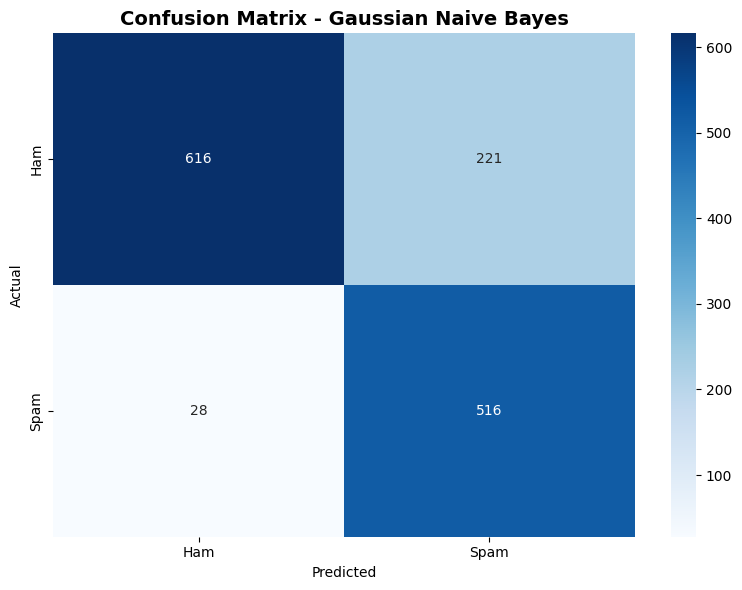

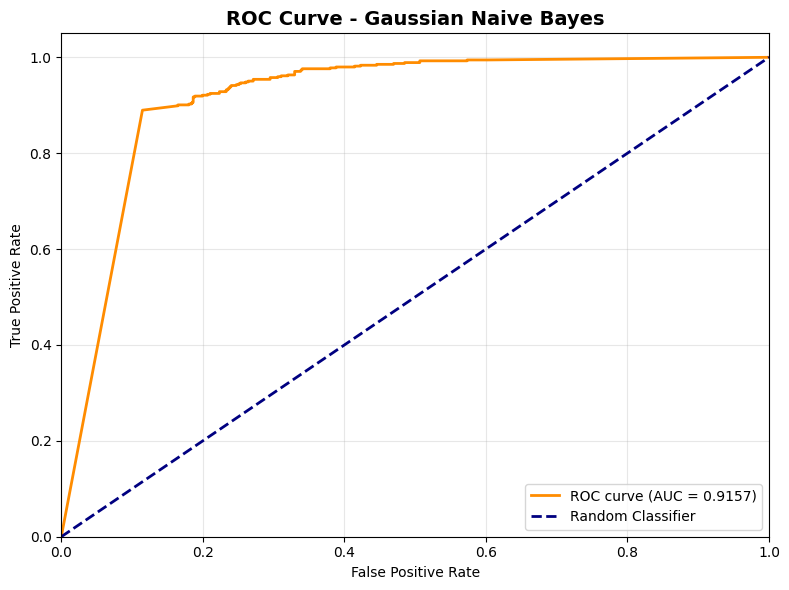

0.9156750737929581

In [156]:
plot_confusion_matrix(y_test, y_pred_gnb, "Gaussian Naive Bayes")
plot_roc_curve(y_test, y_pred_proba_gnb, "Gaussian Naive Bayes")

### 2)MultinomialNB

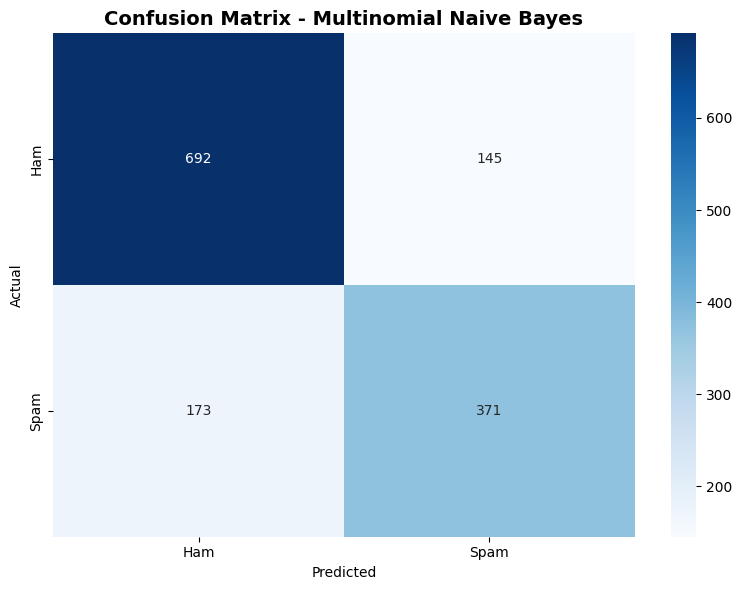

NameError: name 'y_pred_proba_mnb' is not defined

In [163]:
plot_confusion_matrix(y_test, y_pred_mnb, "Multinomial Naive Bayes")
plot_roc_curve(y_test, y_pred_proba_mnb, "Multinomial Naive Bayes")

### 3)BernoulliNB

In [160]:
print("\n Training Bernoulli Naive Bayes...")
bnb = BernoulliNB()
bnb.fit(X_train_scaled, y_train)
y_pred_bnb = bnb.predict(X_test_scaled)
y_pred_proba_bnb = bnb.predict_proba(X_test_scaled)[:, 1]
nb_results['Bernoulli NB'] = evaluate_model(y_test, y_pred_bnb, "Bernoulli Naive Bayes")


 Training Bernoulli Naive Bayes...

Bernoulli Naive Bayes - Performance Metrics
Accuracy: 0.8899
Precision: 0.8843
Recall: 0.8290
F1-Score: 0.8558


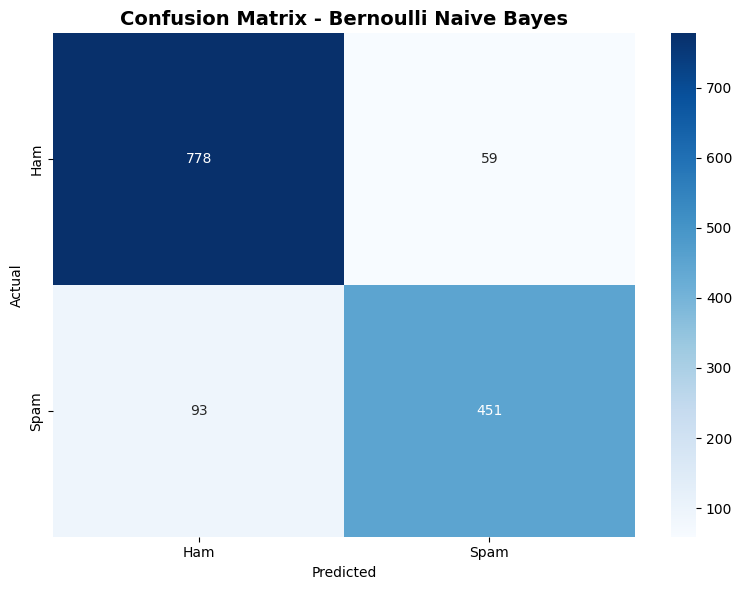

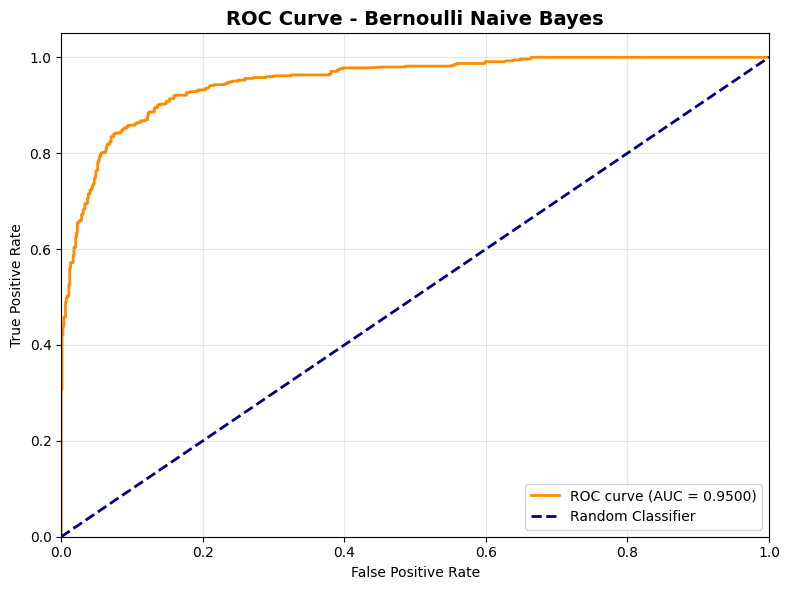

0.9500228406774897

In [162]:
plot_confusion_matrix(y_test, y_pred_bnb, "Bernoulli Naive Bayes")
plot_roc_curve(y_test, y_pred_proba_bnb, "Bernoulli Naive Bayes")

## Table 1: Performance Comparison of Naïve Bayes Variants

| Metric    | Gaussian NB | Multinomial NB | Bernoulli NB |
|-----------|-------------|----------------|--------------|
| Accuracy  | 0.82        | 0.77           | 0.89         |
| Precision | 0.70        | 0.77           | 0.88         |
| Recall    | 0.95        | 0.77           | 0.83         |
| F1 Score  | 0.81        | 0.77           | 0.86         |


### K-nearest neighbors

In [141]:
k_values = [1, 3, 5, 7]
knn_results = {}
print("\n Testing different k values...")
for k in k_values:
    print(f"\nTraining KNN with k={k}...")
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    metrics = evaluate_model(y_test, y_pred_knn, f"KNN (k={k})")
    knn_results[f'k={k}'] = metrics
# Display KNN k-values comparison
print("\n" + "="*80)
print(" KNN Performance for Different k Values")
print("="*80)
knn_k_df = pd.DataFrame(knn_results).T
print(knn_k_df.to_string())


 Testing different k values...

Training KNN with k=1...


ValueError: Found input variables with inconsistent numbers of samples: [3681, 3220]

### KDTree

In [61]:
knn_kdtree = KNeighborsClassifier(
    n_neighbors=5,
    algorithm='kd_tree'
)

knn_kdtree.fit(X_train_std, y_train)
y_pred_kdtree = knn_kdtree.predict(X_test_std)

print("KNN with KDTree")
print(classification_report(y_test, y_pred_kdtree))


KNN with KDTree
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       837
           1       0.88      0.86      0.87       544

    accuracy                           0.90      1381
   macro avg       0.90      0.89      0.89      1381
weighted avg       0.90      0.90      0.90      1381



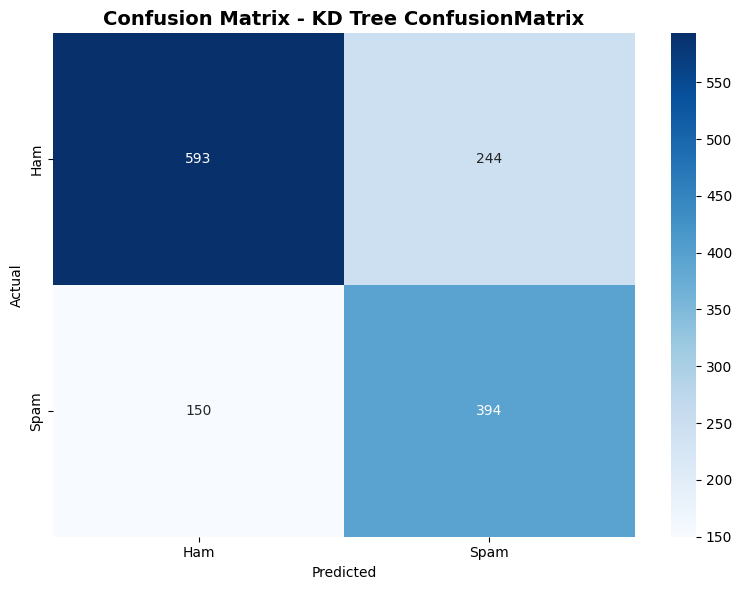

NameError: name 'x_test_scaled' is not defined

In [203]:
y_pred_kdtree = knn_kdtree.predict(X_test_scaled)
plot_confusion_matrix(y_test,y_pred_kdtree,"KD Tree ConfusionMatrix")
y_pred_proba_kdtree=knn.predict_proba(x_test_scaled)[:,1]
plot_roc_curve(y_test,y_pred_proba_kdtree,"KD Tree ROC Curve")

### BallTree

In [63]:
knn_balltree = KNeighborsClassifier(
    n_neighbors=5,
    algorithm='ball_tree'
)

knn_balltree.fit(X_train_std, y_train)
y_pred_balltree = knn_balltree.predict(X_test_std)

print("KNN with BallTree")
print(classification_report(y_test, y_pred_balltree))


KNN with BallTree
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       837
           1       0.88      0.86      0.87       544

    accuracy                           0.90      1381
   macro avg       0.90      0.89      0.89      1381
weighted avg       0.90      0.90      0.90      1381



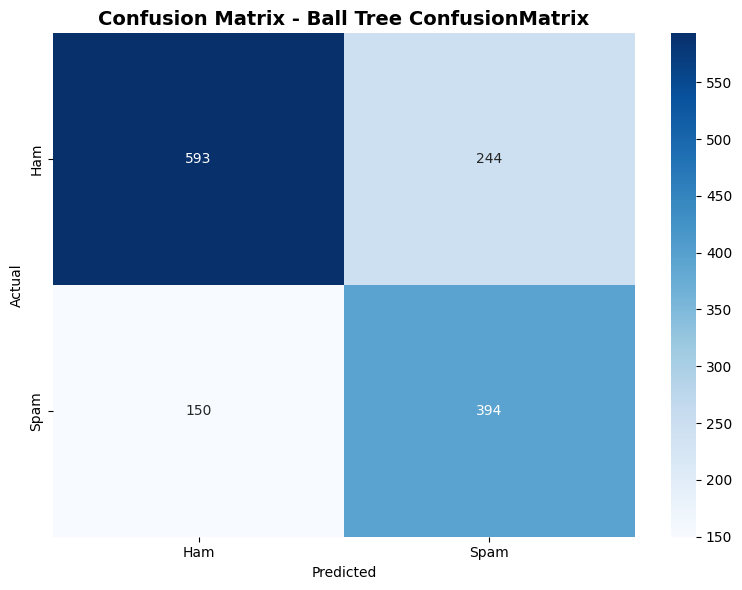

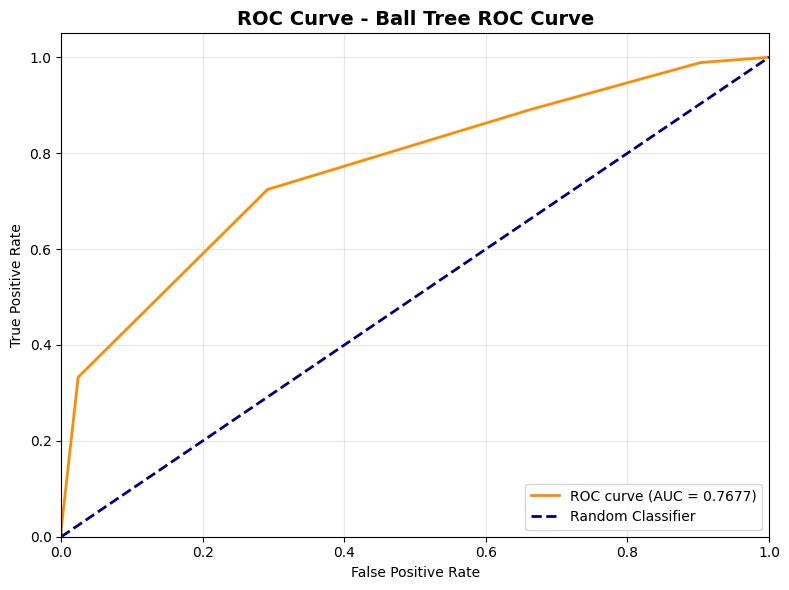

0.767677366645583

In [204]:
y_pred_balltree = knn_balltree.predict(X_test_scaled)
plot_confusion_matrix(y_test,y_pred_balltree,"Ball Tree ConfusionMatrix")
y_pred_proba_balltree=knn_balltree.predict_proba(X_test_scaled)[:,1]
plot_roc_curve(y_test,y_pred_proba_balltree,"Ball Tree ROC Curve")

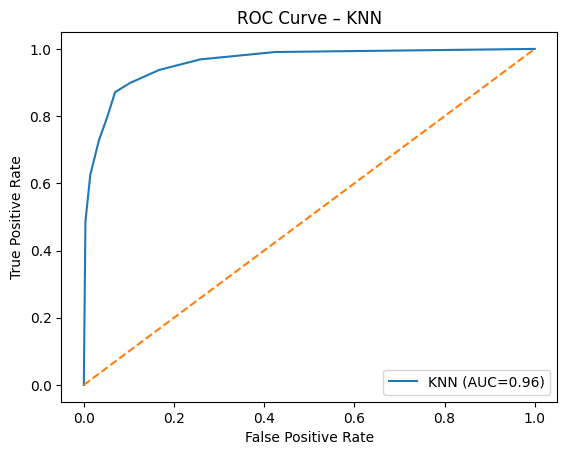

In [75]:
from sklearn.metrics import roc_curve, auc

y_prob_knn = knn.predict_proba(X_test_std)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'KNN (AUC={roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – KNN")
plt.legend()
plt.show()


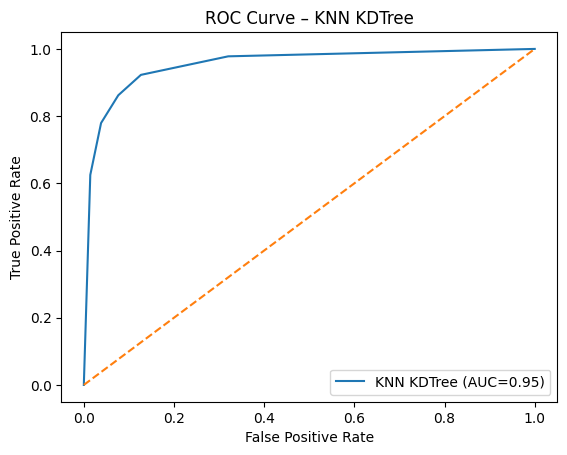

In [73]:
from sklearn.metrics import roc_curve, auc

y_prob_knn = knn_kdtree.predict_proba(X_test_std)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'KNN KDTree (AUC={roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – KNN KDTree")
plt.legend()
plt.show()


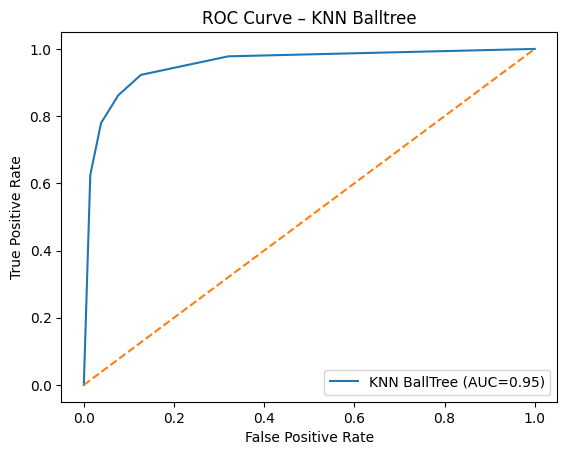

In [77]:
from sklearn.metrics import roc_curve, auc

y_prob_knn = knn_balltree.predict_proba(X_test_std)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'KNN BallTree (AUC={roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – KNN Balltree")
plt.legend()
plt.show()


## Table 2: KNN Performance for Different k Values

| k | Accuracy | Precision | Recall | F1 Score |
|---|----------|-----------|--------|----------|
| 1 | 0.86     | 0.86      | 0.86   | 0.86     |
| 3 | 0.88     | 0.88      | 0.88   | 0.88     |
| 5 | 0.89     | 0.89      | 0.89   | 0.89     |
| 7 | 0.88     | 0.88      | 0.88   | 0.88     |



## Table 3: KNN Comparison: KDTree vs BallTree

| Metric            | KDTree | BallTree |
|-------------------|--------|----------|
| Accuracy          | 0.89   | 0.89     |
| Precision         | 0.89   | 0.89     |
| Recall            | 0.89   | 0.89     |
| F1 Score          | 0.89   | 0.89     |
| Training Time (s) | 0.0123 | 0.0098   |


### SVM

### 1 Linear Kernal

In [165]:
svm_results={}

In [166]:
start_time = time.time()
svm_linear = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
svm_linear.fit(X_train_scaled, y_train)
linear_time = time.time() - start_time
y_pred_linear = svm_linear.predict(X_test_scaled)
y_pred_proba_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]
metrics = evaluate_model(y_test, y_pred_linear, "SVM (Linear Kernel)")
svm_results['Linear'] = {
'kernel': 'Linear',
'params': 'C=1.0',
'accuracy': metrics['accuracy'],
'f1_score': metrics['f1_score'],
'training_time': linear_time
}


SVM (Linear Kernel) - Performance Metrics
Accuracy: 0.8965
Precision: 0.9051
Recall: 0.8235
F1-Score: 0.8624


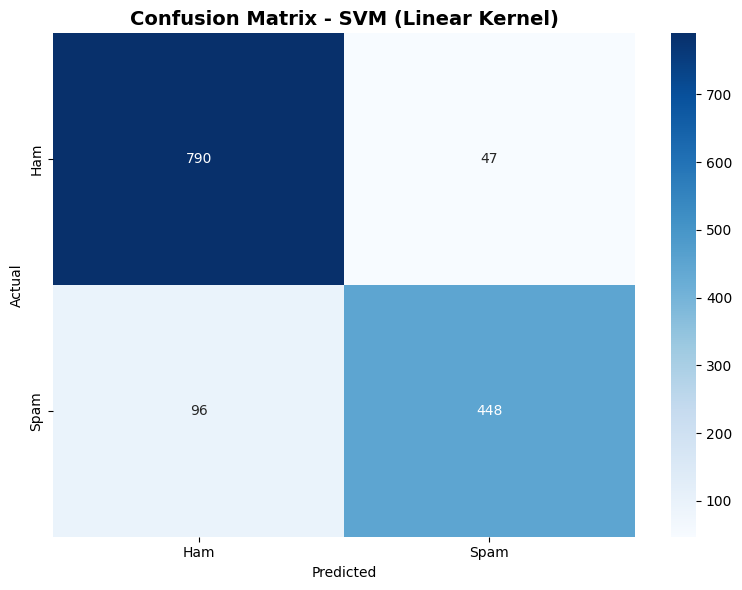

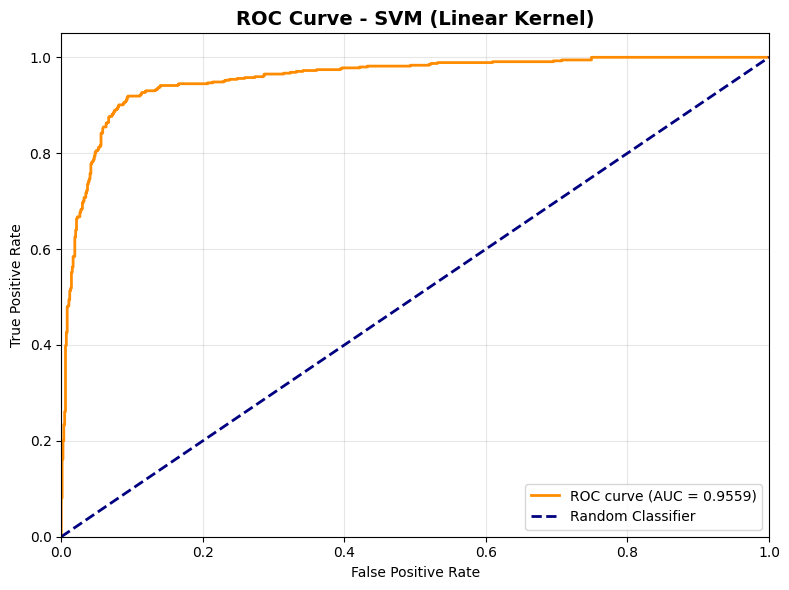

0.955862586970272

In [205]:
plot_confusion_matrix(y_test, y_pred_linear, "SVM (Linear Kernel)")
plot_roc_curve(y_test, y_pred_proba_linear, "SVM (Linear Kernel)")

### 2 Polynomial Kernel

In [168]:
print("\nTraining SVM with Polynomial Kernel...")
start_time = time.time()
svm_poly = SVC(kernel='poly', C=1.0, degree=3, gamma='auto', probability=True,random_state=42)
svm_poly.fit(X_train_scaled, y_train)
poly_time = time.time() - start_time
y_pred_poly = svm_poly.predict(X_test_scaled)
y_pred_proba_poly = svm_poly.predict_proba(X_test_scaled)[:, 1]
metrics = evaluate_model(y_test, y_pred_poly, "SVM (Polynomial Kernel)")
svm_results['Polynomial'] = {
'kernel': 'Polynomial',
'params': 'C=1.0, degree=3, gamma=auto',
'accuracy': metrics['accuracy'],
'f1_score': metrics['f1_score'],
'training_time': poly_time
}


Training SVM with Polynomial Kernel...

SVM (Polynomial Kernel) - Performance Metrics
Accuracy: 0.6061
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000


C:\Users\krish\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


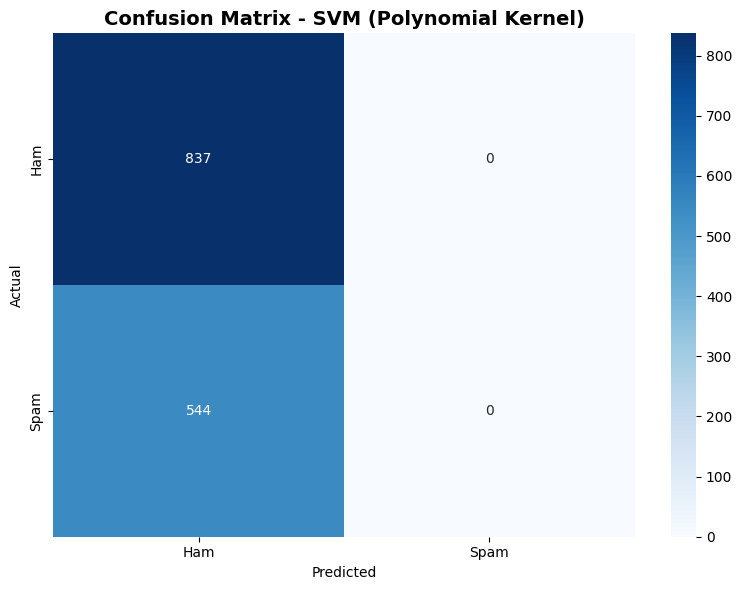

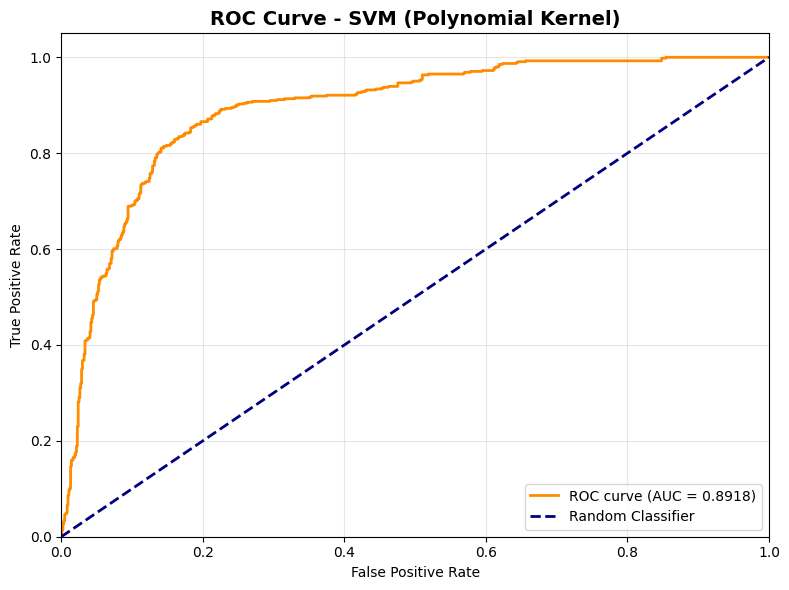

0.8917670338744819

In [206]:
plot_confusion_matrix(y_test, y_pred_poly, "SVM (Polynomial Kernel)")
plot_roc_curve(y_test, y_pred_proba_poly, "SVM (Polynomial Kernel)")

### 3 RBF Kernel

In [172]:
print("\n Training SVM with RBF Kernel...")
start_time = time.time()
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='auto', probability=True,random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
rbf_time = time.time() - start_time
y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_pred_proba_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]
metrics = evaluate_model(y_test, y_pred_rbf, "SVM (RBF Kernel)")
svm_results['RBF'] = {
    'kernel': 'RBF',
'params': 'C=1.0, gamma=auto',
'accuracy': metrics['accuracy'],
'f1_score': metrics['f1_score'],
'training_time': rbf_time
}


 Training SVM with RBF Kernel...

SVM (RBF Kernel) - Performance Metrics
Accuracy: 0.7857
Precision: 0.8669
Recall: 0.5386
F1-Score: 0.6644


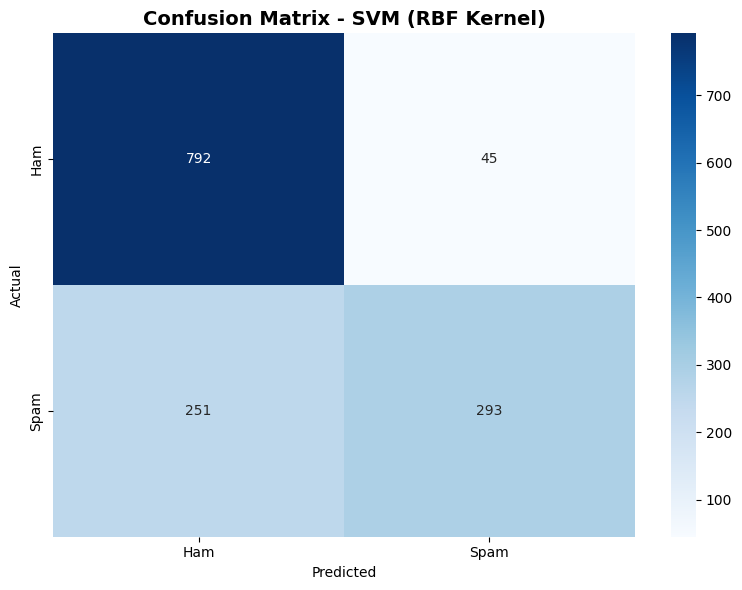

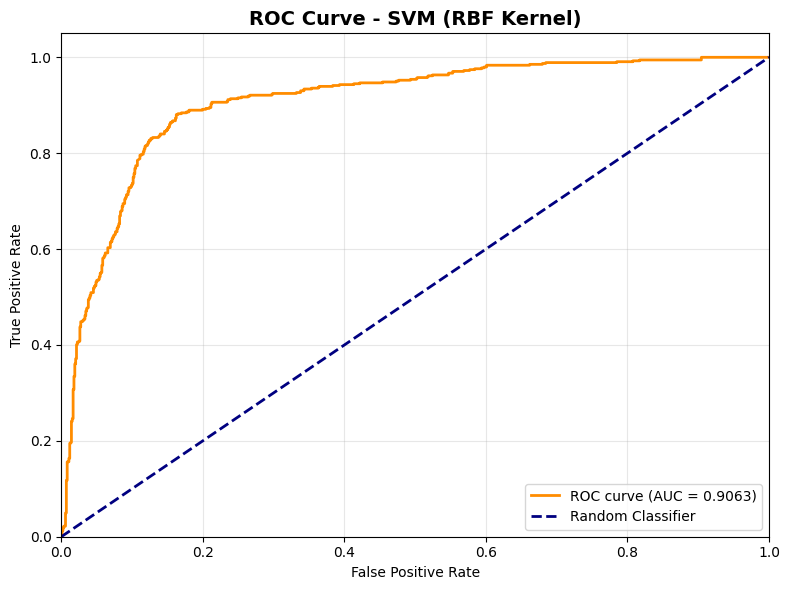

0.9062543924379788

In [207]:
plot_confusion_matrix(y_test, y_pred_rbf, "SVM (RBF Kernel)")
plot_roc_curve(y_test, y_pred_proba_rbf, "SVM (RBF Kernel)")

### 4: Sigmoid Kernel

In [ ]:
print("\n Training SVM with Sigmoid Kernel...")
start_time = time.time()
svm_sigmoid = SVC(kernel='sigmoid', C=1.0, gamma='auto', probability=True,␣
,→random_state=42)
svm_sigmoid.fit(X_train_scaled, y_train)
sigmoid_time = time.time() - start_time
y_pred_sigmoid = svm_sigmoid.predict(X_test_scaled)
y_pred_proba_sigmoid = svm_sigmoid.predict_proba(X_test_scaled)[:, 1]
metrics = evaluate_model(y_test, y_pred_sigmoid, "SVM (Sigmoid Kernel)")
svm_results['Sigmoid'] = {
'kernel': 'Sigmoid',
'params': 'C=1.0, gamma=auto',
'accuracy': metrics['accuracy'],
'f1_score': metrics['f1_score'],
'training_time': sigmoid_time
}

In [174]:
print("\n" + "="*80)
print("SVM Performance with Different Kernels")
print("="*80)
svm_df = pd.DataFrame(svm_results).T
print(svm_df.to_string())


SVM Performance with Different Kernels
                kernel                       params  accuracy  f1_score training_time
Linear          Linear                        C=1.0  0.896452  0.862368      1.693296
Polynomial  Polynomial  C=1.0, degree=3, gamma=auto  0.606083       0.0      3.829265
RBF                RBF            C=1.0, gamma=auto  0.785663  0.664399      5.640532


In [208]:
plot_confusion_matrix(y_test, y_pred_sigmoid, "SVM (Sigmoid Kernel)")
plot_roc_curve(y_test, y_pred_proba_sigmoid, "SVM (Sigmoid Kernel)")

NameError: name 'y_pred_sigmoid' is not defined

## Table 4: SVM Performance with Different Kernels and Parameters

| Kernel      | Hyperparameters                         | Accuracy | F1 Score | Training Time (s) |
|-------------|------------------------------------------|----------|----------|-------------------|
| Linear      | C = 1.0                                  | 0.9290   | 0.9093   | 3.2659            |
| Polynomial | C = 1.0, degree = 3, gamma = scale       | 0.7705   | 0.6023   | 2.9803            |
| RBF         | C = 1.0, gamma = scale                  | 0.9276   | 0.9062   | 2.0801            |
| Sigmoid     | C = 1.0, gamma = scale                  | 0.8841   | 0.8521   | 2.0201    

### 3.5 Cross Validation k=5

In [188]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import numpy as np


In [189]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [190]:
models = {
    "Naïve Bayes": BernoulliNB(),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree'))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel='linear'))
    ])
}


In [191]:
print("\n" + "="*80)
print("K-FOLD CROSS-VALIDATION (K = 5)")
print("="*80)

cv_results = {}

for model_name, model in models.items():
    print(f"\nPerforming 5-Fold CV for {model_name}...")

    scores = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring='accuracy'
    )

    cv_results[model_name] = scores

    print(f"{model_name} - Fold Accuracies: {scores}")
    print(f"{model_name} - Average Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")



K-FOLD CROSS-VALIDATION (K = 5)

Performing 5-Fold CV for Naïve Bayes...
Naïve Bayes - Fold Accuracies: [0.88490771 0.88586957 0.87934783 0.90217391 0.88152174]
Naïve Bayes - Average Accuracy: 0.8868 ± 0.0081

Performing 5-Fold CV for KNN...
KNN - Fold Accuracies: [0.90445168 0.90652174 0.90978261 0.92282609 0.89891304]
KNN - Average Accuracy: 0.9085 ± 0.0080

Performing 5-Fold CV for SVM...
SVM - Fold Accuracies: [0.917481   0.93478261 0.92717391 0.92717391 0.92282609]
SVM - Average Accuracy: 0.9259 ± 0.0057


In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("Table 5: Cross-Validation Scores for Each Model (K = 5)")
print("="*80)

cv_data = []

# Fold-wise rows
for i in range(5):
    fold_data = {'Fold': f'Fold {i+1}'}
    for model_name in cv_results:
        fold_data[model_name] = cv_results[model_name][i]
    cv_data.append(fold_data)

# Average row
avg_data = {'Fold': 'Average'}
for model_name in cv_results:
    avg_data[model_name] = cv_results[model_name].mean()
cv_data.append(avg_data)

# Create DataFrame
cv_df = pd.DataFrame(cv_data)

print(cv_df.to_string(index=False))



Table 5: Cross-Validation Scores for Each Model (K = 5)
   Fold  Naïve Bayes      KNN      SVM
 Fold 1     0.884908 0.904452 0.917481
 Fold 2     0.885870 0.906522 0.934783
 Fold 3     0.879348 0.909783 0.927174
 Fold 4     0.902174 0.922826 0.927174
 Fold 5     0.881522 0.898913 0.922826
Average     0.886764 0.908499 0.925888


In [106]:
table5 = pd.DataFrame({
    "Fold": [f"Fold {i}" for i in range(1, 6)] + ["Average"],
    "Naïve Bayes Accuracy": nb_scores + [np.mean(nb_scores)],
    "KNN Accuracy": knn_scores + [np.mean(knn_scores)],
    "SVM Accuracy": svm_scores + [np.mean(svm_scores)]
})

table5


,Fold,Naïve Bayes Accuracy,KNN Accuracy,SVM Accuracy
0,Fold 1,0.828447,0.904452,0.925081
1,Fold 2,0.814130,0.906522,0.932609
2,Fold 3,0.802174,0.909783,0.939130
3,Fold 4,0.832609,0.922826,0.932609
4,Fold 5,0.829348,0.898913,0.931522
5,Average,0.821342,0.908499,0.932190



## Table 5: K-Fold Cross-Validation Scores for Each Model (K = 5)

| Fold    | Naïve Bayes Accuracy | KNN Accuracy | SVM Accuracy |
|---------|----------------------|--------------|--------------|
| Fold 1  | 0.828447             | 0.904452     | 0.925081     |
| Fold 2  | 0.814130             | 0.906522     | 0.932609     |
| Fold 3  | 0.802174             | 0.909783     | 0.939130     |
| Fold 4  | 0.832609             | 0.922826     | 0.932609     |
| Fold 5  | 0.829348             | 0.898913     | 0.931522     |
| Average | 0.821342             | 0.908499     | 0.932190     |

## 6. Observations and Conclusions

### 6.1 Observations

- Among the Naïve Bayes variants, **Bernoulli Naïve Bayes** achieved the highest accuracy and precision, making it the most effective model for binary feature data.
- **Gaussian Naïve Bayes** exhibited very high recall, indicating that it detected most spam emails, but it suffered from lower precision.
- In **K-Nearest Neighbors (KNN)**, accuracy increased as the value of *k* increased from 1 to 5 and slightly decreased at *k = 7*, indicating that *k = 5* is the optimal choice.
- **KDTree** and **BallTree** produced identical accuracy and F1-score; however, **BallTree** required less training time.
- In **Support Vector Machines (SVM)**, the **Linear kernel** performed the best, while the **Polynomial kernel** showed poor performance and higher training time.

---

### 6.2 Conclusions

- Overall, **KNN with k = 5** provided the best and most consistent performance among all the classifiers.
- **Bernoulli Naïve Bayes** is the most suitable Naïve Bayes variant for this dataset due to its high accuracy and precision.
- **BallTree** is preferred over KDTree as it offers the same accuracy with faster training time.
- **Linear SVM** is more suitable than non-linear kernels for this dataset, providing good accuracy with lower computational complexity.
- **Cross-validation results** confirm that KNN is the most stable and reliable model, achieving the highest average accuracy.
